# Loan Default Prediction with Cost-Based Threshold Optimization

## Problem Statement and Objective

The objective of this task is to predict whether a customer is likely to default on a loan.

In this task, two machine learning models are used:

1. Logistic Regression
2. CatBoost Classifier

After model training, cost-based threshold optimization is applied. This helps the business choose the best decision threshold by reducing the cost of wrong predictions.

The main goal is not only to improve prediction accuracy but also to minimize business loss caused by loan default decisions.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

## Dataset Description and Loading

The dataset used in this task is a credit risk dataset.

It contains customer and loan-related information. The target column is `loan_status`, which shows whether a customer defaulted or not.

The dataset is loaded using pandas.

In [2]:
# Load dataset
data = pd.read_csv("Credit Risk Dataset.csv")

# Display first 5 rows
data.head()
# Dataset shape
print("Dataset shape:", data.shape)
# Dataset information
data.info()
# Display column names
data.columns
# Target distribution
data["loan_status"].value_counts()
# Target distribution percentage
data["loan_status"].value_counts(normalize=True) * 100

Dataset shape: (32581, 29)
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  str    
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  str    
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  str    
 6   loan_grade                  32581 non-null  str    
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  str    
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender         

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

## Data Cleaning and Preprocessing

In this section, the dataset is cleaned before model training.

The following steps are performed:

- Drop ID column if present
- Separate features and target variable
- Identify numeric and categorical columns
- Handle missing values

In [3]:
# Drop ID column if it exists because it does not help prediction
if "SK_ID_CURR" in data.columns:
    data = data.drop(columns=["SK_ID_CURR"])

# Separate target and features
y = data["loan_status"]
X = data.drop(columns=["loan_status"])

# Display target values
y.value_counts()
# Convert object columns to string to avoid pandas dtype warnings
object_cols = X.columns[X.dtypes == "object"]

for col in object_cols:
    X[col] = X[col].astype("string")

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["number"]).columns
categorical_cols = X.select_dtypes(include=["string", "category"]).columns

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numeric columns: 16
Number of categorical columns: 12


## Handling Missing Values

Missing values are handled separately for numeric and categorical columns.

- Numeric columns are filled using median values.
- Categorical columns are filled using mode values.

In [4]:
# Fill numeric missing values with median
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Check total missing values after cleaning
print("Missing values after cleaning:", X.isnull().sum().sum())

Missing values after cleaning: 0


## Exploratory Data Analysis

EDA helps us understand the data before building models.

In this section, we analyze:

- Target distribution
- Numeric feature distributions
- Correlation among numeric features

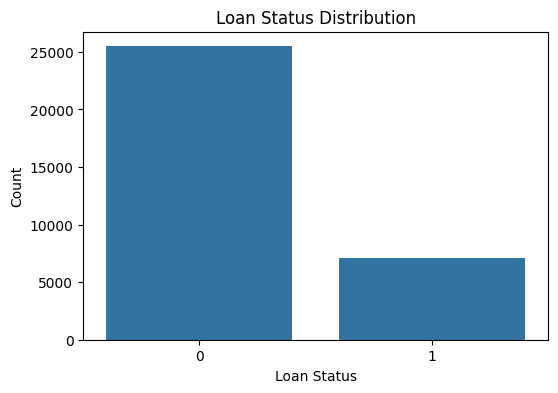

In [5]:
# Target distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

In [6]:
# Percentage distribution of target
target_percentage = y.value_counts(normalize=True) * 100
target_percentage

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

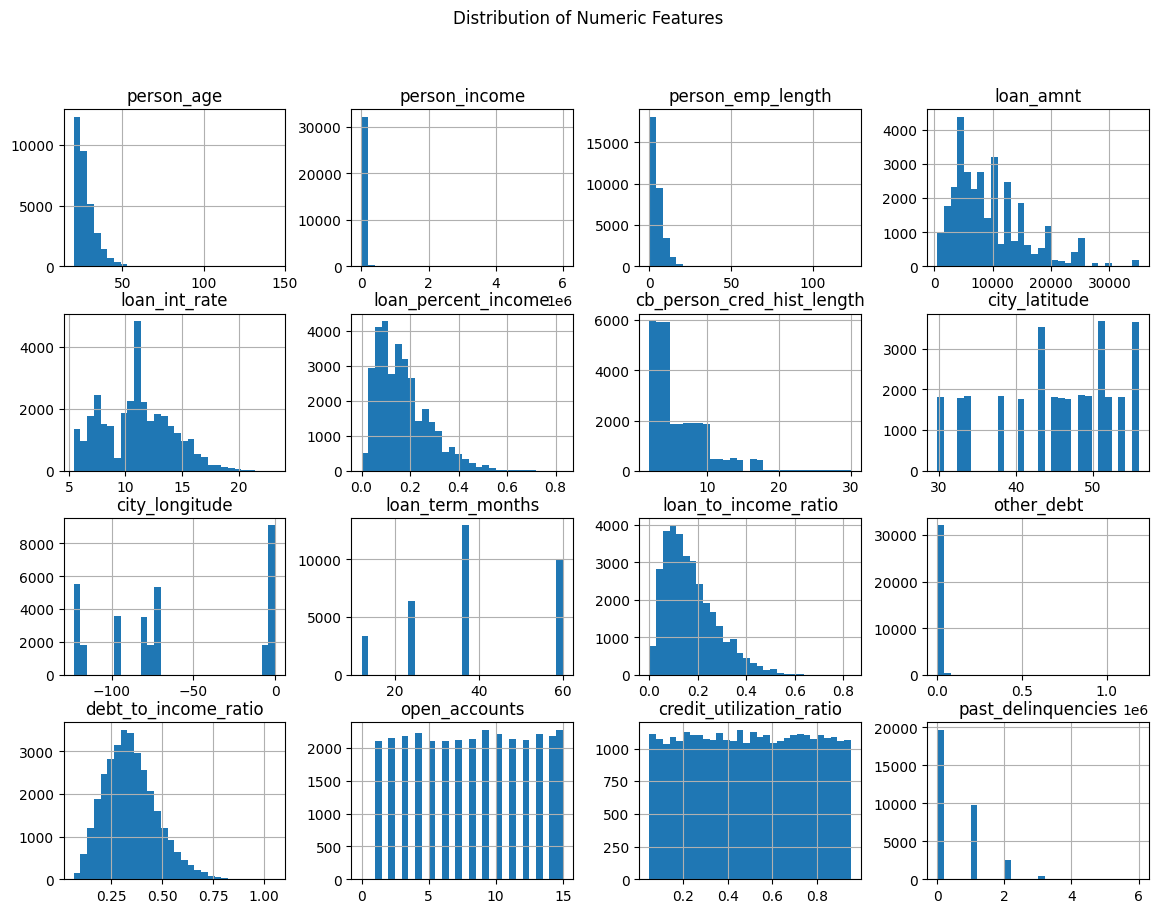

In [7]:
# Plot histograms of first few numeric columns
X[numeric_cols].hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribution of Numeric Features")
plt.show()

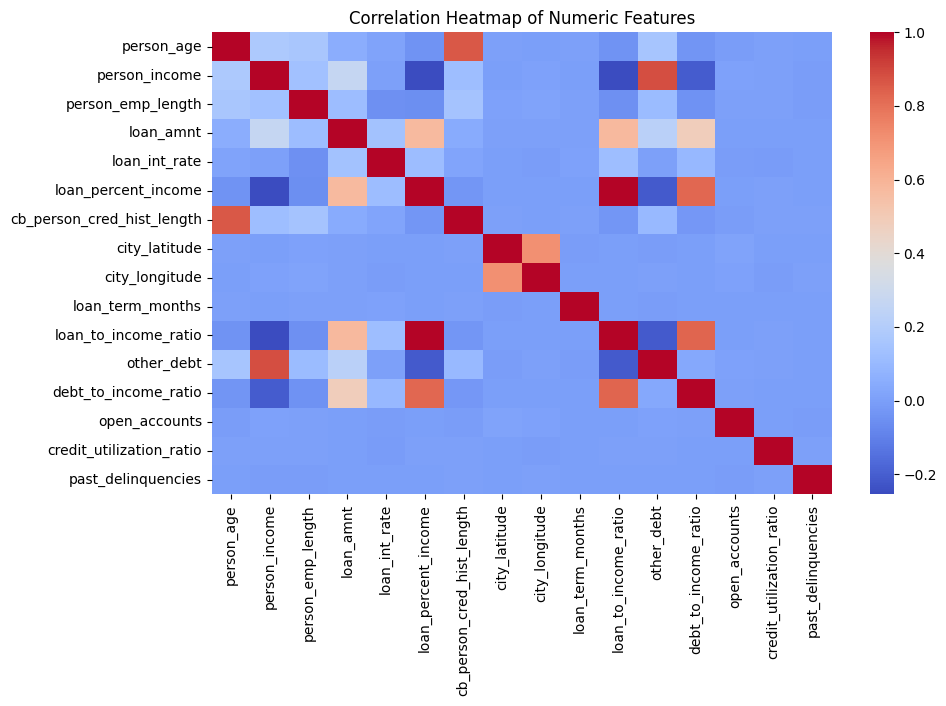

In [8]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(10, 6))
sns.heatmap(X[numeric_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Encoding Categorical Features

Machine learning models require numerical input.

Categorical columns are converted into numeric format using one-hot encoding.

In [9]:
# One-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (32581, 32648)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,city_latitude,city_longitude,loan_term_months,...,city_Ottawa,city_Quebec City,city_San Francisco,city_Swansea,city_Toronto,city_Vancouver,city_Victoria,employment_type_Part-time,employment_type_Self-employed,employment_type_Unemployed
0,22,59000,123.0,35000,16.02,0.59,3,43.6532,-79.3832,36,...,False,False,False,False,True,False,False,False,True,False
1,21,9600,5.0,1000,11.14,0.10,2,43.6532,-79.3832,36,...,False,False,False,False,True,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,51.6214,-3.9436,36,...,False,False,False,True,False,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,49.2827,-123.1207,12,...,False,False,False,False,False,True,False,True,False,False
4,24,54400,8.0,35000,14.27,0.55,4,42.8864,-78.8784,36,...,False,False,False,False,False,False,False,True,False,False


## Train-Test Split

The dataset is divided into training and testing data.

80% of the data is used for training and 20% is used for testing.

Stratification is used to maintain the same class distribution in train and test sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (26064, 32648)
Testing data shape: (6517, 32648)


## Feature Scaling

Logistic Regression is sensitive to feature scale.

StandardScaler is used to scale the training and testing features.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model

Logistic Regression is used as a baseline classification model.

Class weight is set to balanced because loan default datasets are usually imbalanced.

In [12]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

log_auc = roc_auc_score(y_test, log_probs)

print("Logistic Regression AUC:", round(log_auc, 4))

Logistic Regression AUC: 0.8564


## CatBoost Model

CatBoost is a powerful boosting algorithm that performs well on classification problems.

In this task, CatBoost is used to predict loan default risk.

In [13]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    class_weights=[1, 5]
)

cat_model.fit(X_train, y_train)

cat_probs = cat_model.predict_proba(X_test)[:, 1]

cat_auc = roc_auc_score(y_test, cat_probs)

print("CatBoost AUC:", round(cat_auc, 4))

CatBoost AUC: 0.9299


## Model Evaluation at Decision Threshold

By default, classification models use a threshold of 0.50.

If predicted probability is greater than or equal to the threshold, the customer is classified as default.

This function evaluates the model at any selected threshold.

In [14]:
def evaluate_at_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)

    cm = confusion_matrix(y_true, predictions)

    print(f"Evaluation at Threshold = {threshold:.2f}")
    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_true, predictions, zero_division=0))

    return cm
    print("--- Logistic Regression Evaluation at 0.50 Threshold ---")
evaluate_at_threshold(y_test, log_probs, 0.50)
print("--- CatBoost Evaluation at 0.50 Threshold ---")
evaluate_at_threshold(y_test, cat_probs, 0.50)

Evaluation at Threshold = 0.50

Confusion Matrix:
[[4955  140]
 [ 939  483]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      5095
           1       0.78      0.34      0.47      1422

    accuracy                           0.83      6517
   macro avg       0.81      0.66      0.69      6517
weighted avg       0.83      0.83      0.81      6517

--- CatBoost Evaluation at 0.50 Threshold ---
Evaluation at Threshold = 0.50

Confusion Matrix:
[[4523  572]
 [ 272 1150]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91      5095
           1       0.67      0.81      0.73      1422

    accuracy                           0.87      6517
   macro avg       0.81      0.85      0.82      6517
weighted avg       0.88      0.87      0.87      6517



array([[4523,  572],
       [ 272, 1150]])

## Business Cost Definition

In loan default prediction, not all wrong predictions have the same cost.

False Positive:
The model predicts default, but the customer would not default.  
The business may reject a good customer.

False Negative:
The model predicts no default, but the customer actually defaults.  
The business may give a loan to a risky customer.

False Negative is usually more costly than False Positive.

In [15]:
# Business cost values
false_positive_cost = 1
false_negative_cost = 10

print("False Positive Cost:", false_positive_cost)
print("False Negative Cost:", false_negative_cost)

False Positive Cost: 1
False Negative Cost: 10


## Cost-Based Threshold Optimization

Different decision thresholds create different numbers of false positives and false negatives.

The purpose of threshold optimization is to find the threshold with the minimum total business cost.

In [17]:
# --------------------------------------------------
# 13. Cost-Based Threshold Optimization
# --------------------------------------------------

def calculate_business_cost(y_true, probabilities, threshold, fp_cost, fn_cost):
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()

    total_cost = (fp * fp_cost) + (fn * fn_cost)

    return total_cost, tn, fp, fn, tp


def find_best_threshold(y_true, probabilities, fp_cost, fn_cost):
    thresholds = np.arange(0.01, 1.00, 0.01)

    results = []

    for threshold in thresholds:
        total_cost, tn, fp, fn, tp = calculate_business_cost(
            y_true,
            probabilities,
            threshold,
            fp_cost,
            fn_cost
        )

        results.append({
            "threshold": threshold,
            "total_cost": total_cost,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    results_df = pd.DataFrame(results)

    best_row = results_df.loc[results_df["total_cost"].idxmin()]

    return best_row, results_df


# Find best threshold for Logistic Regression
best_log_threshold, log_cost_results = find_best_threshold(
    y_test,
    log_probs,
    false_positive_cost,
    false_negative_cost
)

# Find best threshold for CatBoost
best_cat_threshold, cat_cost_results = find_best_threshold(
    y_test,
    cat_probs,
    false_positive_cost,
    false_negative_cost
)

print("Best Logistic Regression Threshold:")
display(best_log_threshold)

print("Best CatBoost Threshold:")
display(best_cat_threshold)

Best Logistic Regression Threshold:


threshold        0.01
total_cost    3957.00
tn            3478.00
fp            1617.00
fn             234.00
tp            1188.00
Name: 0, dtype: float64

Best CatBoost Threshold:


threshold        0.33
total_cost    2734.00
tn            3671.00
fp            1424.00
fn             131.00
tp            1291.00
Name: 32, dtype: float64

## Final Evaluation at Best Threshold

After finding the best threshold, both models are evaluated again.

This evaluation shows how model performance changes when business cost is considered.

In [18]:
print("--- Logistic Regression Best Threshold Evaluation ---")
evaluate_at_threshold(
    y_test,
    log_probs,
    best_log_threshold["threshold"]
)
print("--- CatBoost Best Threshold Evaluation ---")
evaluate_at_threshold(
    y_test,
    cat_probs,
    best_cat_threshold["threshold"]
)

--- Logistic Regression Best Threshold Evaluation ---
Evaluation at Threshold = 0.01

Confusion Matrix:
[[3478 1617]
 [ 234 1188]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79      5095
           1       0.42      0.84      0.56      1422

    accuracy                           0.72      6517
   macro avg       0.68      0.76      0.68      6517
weighted avg       0.82      0.72      0.74      6517

--- CatBoost Best Threshold Evaluation ---
Evaluation at Threshold = 0.33

Confusion Matrix:
[[3671 1424]
 [ 131 1291]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83      5095
           1       0.48      0.91      0.62      1422

    accuracy                           0.76      6517
   macro avg       0.72      0.81      0.72      6517
weighted avg       0.86      0.76      0.78      6517



array([[3671, 1424],
       [ 131, 1291]])

## Cost vs Threshold Visualization

This plot shows how total business cost changes at different decision thresholds.

The best threshold is the one where total cost is minimum.

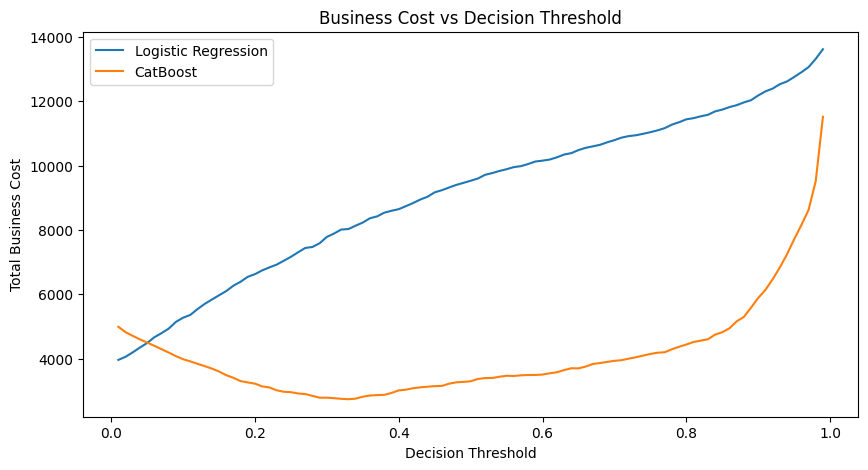

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    log_cost_results["threshold"],
    log_cost_results["total_cost"],
    label="Logistic Regression"
)

plt.plot(
    cat_cost_results["threshold"],
    cat_cost_results["total_cost"],
    label="CatBoost"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost")
plt.title("Business Cost vs Decision Threshold")
plt.legend()
plt.show()

## ROC Curve

ROC curve is used to compare classification model performance.

A higher AUC score means the model is better at separating default and non-default customers.

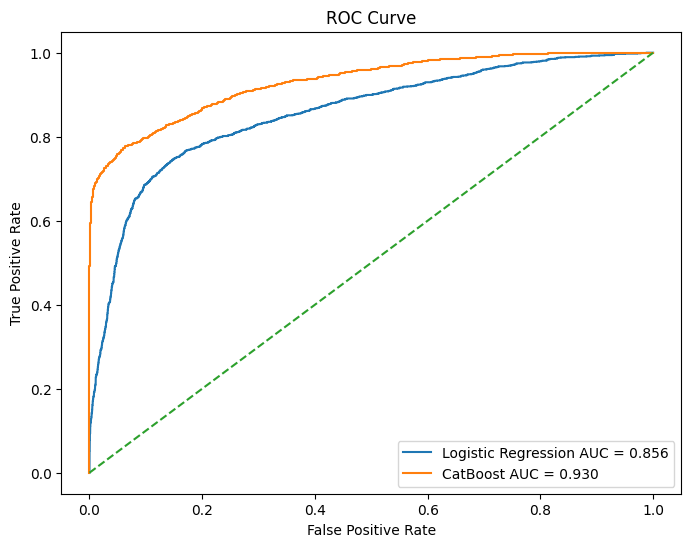

In [20]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
cat_fpr, cat_tpr, _ = roc_curve(y_test, cat_probs)

plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression AUC = {log_auc:.3f}"
)

plt.plot(
    cat_fpr,
    cat_tpr,
    label=f"CatBoost AUC = {cat_auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Feature Importance

Feature importance shows which variables are most useful for predicting loan default.

CatBoost provides feature importance values after training.

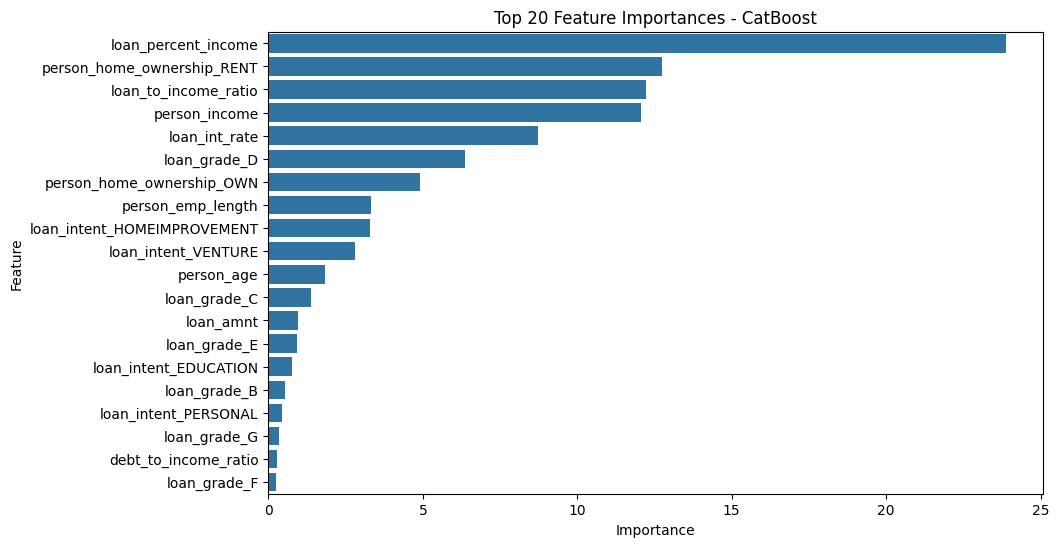

In [21]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(20)
)

plt.title("Top 20 Feature Importances - CatBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Save Results

The threshold cost results and feature importance results are saved as CSV files.

In [22]:
log_cost_results.to_csv("logistic_threshold_cost_results.csv", index=False)
cat_cost_results.to_csv("catboost_threshold_cost_results.csv", index=False)
feature_importance.to_csv("catboost_feature_importance.csv", index=False)

print("Files saved successfully:")
print("logistic_threshold_cost_results.csv")
print("catboost_threshold_cost_results.csv")
print("catboost_feature_importance.csv")

Files saved successfully:
logistic_threshold_cost_results.csv
catboost_threshold_cost_results.csv
catboost_feature_importance.csv


## Final Conclusion

In this task, loan default prediction was performed using Logistic Regression and CatBoost.

The dataset was cleaned, missing values were handled, categorical features were encoded, and the data was split into training and testing sets.

Both models were evaluated using ROC-AUC, confusion matrix, and classification report.

A cost-based threshold optimization approach was applied because false negatives are more costly in loan default prediction. The best threshold was selected based on the minimum total business cost.

CatBoost feature importance was also used to identify the most influential features in predicting loan default.

Overall, this task shows how machine learning can support financial decision-making by predicting default risk and reducing business cost.